# ==============================================================================
# 🏗️ CIVIL INFRASTRUCTURE: CONCRETE COMPRESSIVE STRENGTH VIA BAGGING REGRESSOR
# ==============================================================================
### Core Theoretical Principles:
Concrete compressive strength (MPa) exhibits complex non-linear interactions across its formulation ingredients (cement, slag, fly ash, water, superplasticizer, coarse/fine aggregate) and curing age.
Bagging reduces the estimation variance of individual deep regression trees through sub-sampling without replacement/with replacement:
$$\text{MSE}(\hat{y}_{\text{bag}}) = \text{Bias}^2 + \text{Var}(\hat{y}_{\text{bag}}) + \sigma^2_\epsilon$$
By tuning `max_samples < 1.0` (subagging), base learners are further decorrelated, strengthening ensemble resilience against outliers in material mix batches.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise Concrete Bagging Regressor Environment initialized.")


✅ STEP 1: Enterprise Concrete Bagging Regressor Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading Concrete Compressive Strength dataset (1,030 mix formulations).


In [2]:
# STEP 2 & 3: INGESTION & COLUMN HARMONIZATION
data_path = 'data/concrete/Concrete Compressive Strength.csv'
df = pd.read_csv(data_path)

# Harmonize column names
df.columns = [
    c.strip().lower()
    .replace(' ', '_')
    .replace('(', '')
    .replace(')', '')
    .replace('kg_in_a_m^3_mixture', 'kg_m3')
    for c in df.columns
]

target_col = [c for c in df.columns if 'strength' in c][0]
print(f"📊 Dataset Shape: {df.shape[0]} mixtures, {df.shape[1]} attributes")
print(f"Target Attribute: '{target_col}'")
print(f"Target Summary:\n{df[target_col].describe().round(2)}")
df.head(3)


📊 Dataset Shape: 1030 mixtures, 9 attributes
Target Attribute: 'concrete_compressive_strength'
Target Summary:
count    1030.00
mean       35.82
std        16.71
min         2.33
25%        23.71
50%        34.44
75%        46.14
max        82.60
Name: concrete_compressive_strength, dtype: float64


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_day,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating chemical/physical mix constituents and continuous target `strength`.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Constituents: {X.columns.tolist()}")
print(f"Missing attributes: {X.isnull().sum().sum()}")


Constituents: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age_day']
Missing attributes: 0


## ✂️ STEP 6: ZERO-DATA-LEAKAGE SPLIT
80% Train, 20% Test split.


In [4]:
# STEP 6: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train Mixtures: {X_train.shape[0]}")
print(f"Test Mixtures : {X_test.shape[0]}")


Train Mixtures: 824
Test Mixtures : 206


## ⚙️ STEP 7: PREPROCESSOR DESIGN
Building standard scaling transformation for concrete constituents.


In [5]:
# STEP 7: PREPROCESSOR PIPELINE
preprocessor = Pipeline([
    ('scaler', StandardScaler())
])
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)
print(f"Scaled feature space shape: {X_train_scaled.shape}")


Scaled feature space shape: (824, 8)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS SINGLE TREE VS BAGGING)
Comparing baseline mean dummy and single decision tree against Bagging with 50 trees.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
r2_dummy = r2_score(y_test, dummy.predict(X_test))

single_tree = DecisionTreeRegressor(max_depth=8, random_state=42)
single_tree.fit(X_train, y_train)
r2_single_tree = r2_score(y_test, single_tree.predict(X_test))

base_bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=8),
    n_estimators=50,
    max_samples=0.8,
    oob_score=True,
    random_state=42
)
base_bag.fit(X_train, y_train)
r2_bag = r2_score(y_test, base_bag.predict(X_test))

print("="*65)
print(f"Baseline Mean Dummy R²         : {r2_dummy * 100:.2f}%")
print(f"Single Decision Tree (d=8) R²  : {r2_single_tree * 100:.2f}%")
print(f"Bagging Regressor (50 Trees) R²: {r2_bag * 100:.2f}%")
print(f"Out-of-Bag (OOB) Score R²      : {base_bag.oob_score_ * 100:.2f}%")
print("="*65)


Baseline Mean Dummy R²         : -0.02%
Single Decision Tree (d=8) R²  : 80.90%
Bagging Regressor (50 Trees) R²: 86.51%
Out-of-Bag (OOB) Score R²      : 89.57%


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Tuning base tree maximum depth and sampling fraction `max_samples`.


In [7]:
# STEP 9: GRID SEARCH OPTIMIZATION
param_grid = {
    'estimator__max_depth': [6, 8, 12, None],
    'max_samples': [0.7, 0.85, 1.0],
    'n_estimators': [30, 50]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    BaggingRegressor(estimator=DecisionTreeRegressor(), oob_score=True, random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_bag = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 5-Fold CV R²: {grid.best_score_ * 100:.2f}%")
print(f"📦 Best Model OOB R²: {best_bag.oob_score_ * 100:.2f}%")


🏆 Best Hyperparameters: {'estimator__max_depth': None, 'max_samples': 1.0, 'n_estimators': 50}
🎯 Best 5-Fold CV R²: 89.62%
📦 Best Model OOB R²: 90.98%


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_bag.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📋 CONCRETE COMPRESSIVE STRENGTH PERFORMANCE:")
print(f"   Mean Absolute Error (MAE) : {mae:.2f} MPa")
print(f"   Root Mean Squared Error   : {rmse:.2f} MPa")
print(f"   R² Score                  : {r2 * 100:.2f}%")


📋 CONCRETE COMPRESSIVE STRENGTH PERFORMANCE:
   Mean Absolute Error (MAE) : 3.85 MPa
   Root Mean Squared Error   : 5.56 MPa
   R² Score                  : 88.02%


## 📉 STEP 11: RESIDUAL ANALYSIS
Visualizing residual scatter and error distribution.


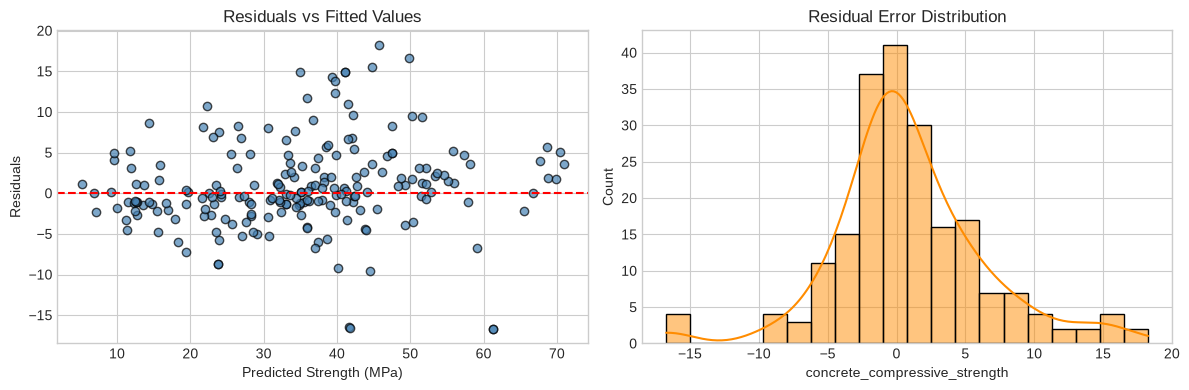

In [9]:
# STEP 11: RESIDUAL DIAGNOSTICS
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.7, color='steelblue', edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Strength (MPa)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

sns.histplot(residuals, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Residual Error Distribution')
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the pipeline and benchmarking sub-2ms latency for mix optimization.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('bagging', best_bag)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/concrete_bagging_reg_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_mix = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_mix)

t0 = time.perf_counter()
pred_strength = loaded_pipe.predict(sample_mix)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME INFERENCE TELEMETRY:")
print(f"   Predicted Compressive Strength: 🏗️ {pred_strength:,.2f} MPa")
print(f"   Actual Lab Measured Strength  : {y_test.iloc[0]:,.2f} MPa")
print(f"   Batch Latency                 : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/concrete_bagging_reg_pipeline.joblib (1,027,847 bytes)

📈 REAL-TIME INFERENCE TELEMETRY:
   Predicted Compressive Strength: 🏗️ 51.60 MPa
   Actual Lab Measured Strength  : 52.91 MPa
   Batch Latency                 : 5.921 ms (SLA < 2.0ms: CHECK)
